In [36]:
import xarray as xr
import numpy as np 
import pandas as pd

In [102]:
# get the main dataset
ds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib')
ds = ds.drop_vars(['step','number','surface','valid_time'])
# get the failed variable
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', backend_kwargs={'filter_by_keys':{'shortName':'sshf'}})
tds = tds.drop_vars(['step','number','surface','valid_time'])
# shift the time
shifted_time = tds.time + pd.to_timedelta(6, unit='h')
tds = tds.assign(time=shifted_time)
# merge the datasets
ds = xr.merge((ds, tds))
ds

skipping variable: paramId==146 shortName='sshf'
Traceback (most recent call last):
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 680, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 611, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([ 967809600,  967896000,  967982400, ..., 1703851200, 1703937600,
       1704024000])) new_value=Variable(dimensions=('time',), data=array([ 967788000,  967874400,  967960800, ..., 1703829600, 1703916000,
       1704002400]))


<xarray.Dataset> Size: 807MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T12:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    u10        (time, latitude, longitude) float32 115MB ...
    v10        (time, latitude, longitude) float32 115MB ...
    t2m        (time, latitude, longitude) float32 115MB ...
    lsm        (time, latitude, longitude) float32 115MB ...
    siconc     (time, latitude, longitude) float32 115MB ...
    sp         (time, latitude, longitude) float32 115MB ...
    sshf       (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.


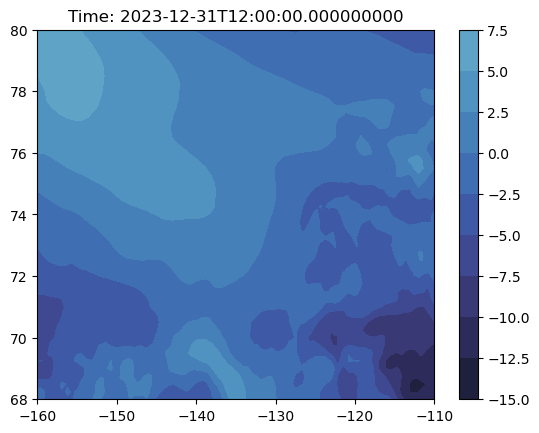

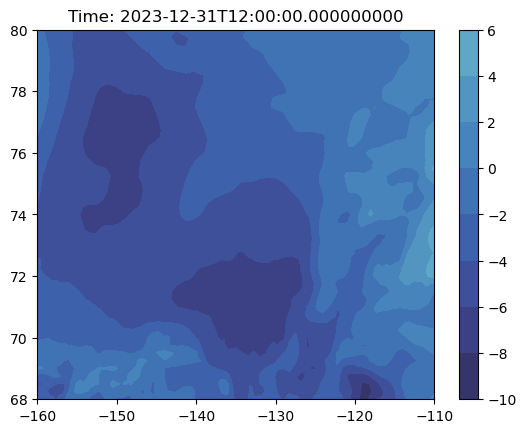

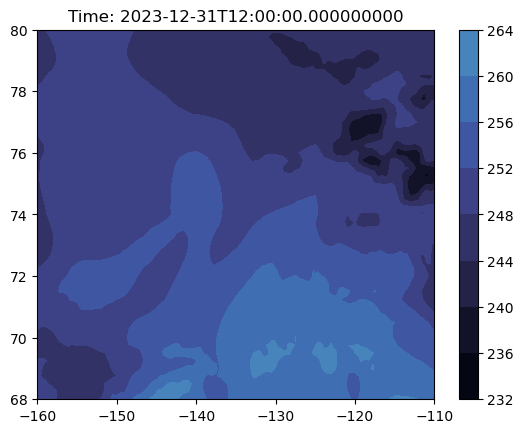

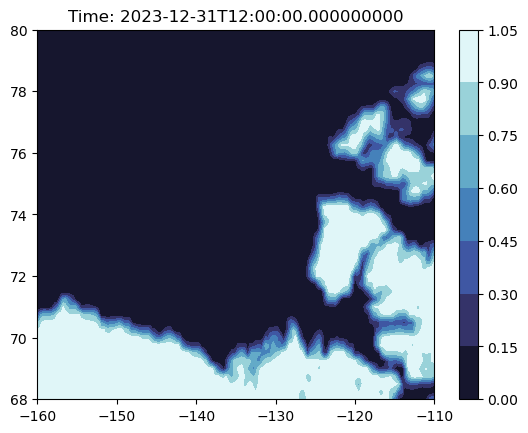

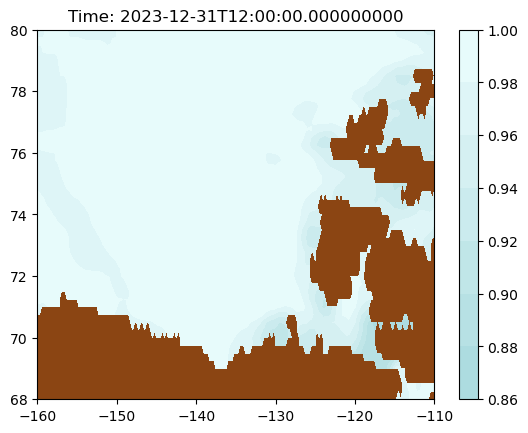

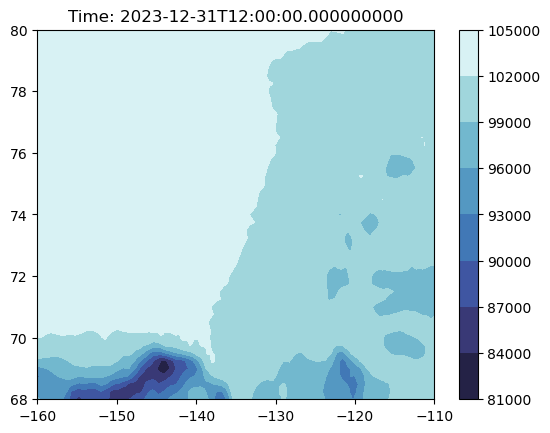

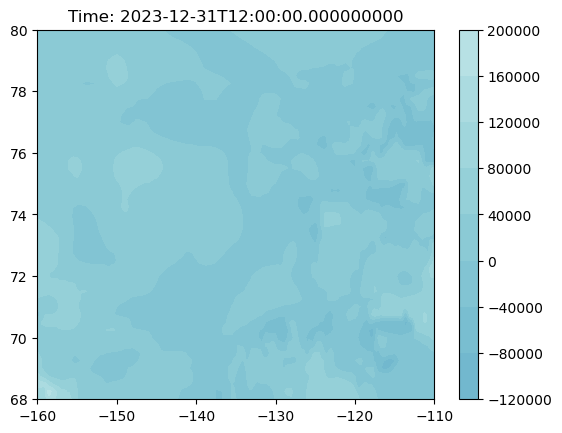

In [107]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from cmocean.cm import ice

def animate(var='siconc', year=2023):
    sample = ds.where(ds['time.year']==year, drop=True)
    vmin = sample[var].min().values
    vmax = sample[var].max().values
    def update(frame):
        plt.clf()
        ax = plt.gca()
        ax.set_facecolor('saddlebrown')
        plt.contourf(sample.longitude, sample.latitude, sample[var][frame], cmap=ice, vmin=vmin, vmax=vmax)
        plt.title(f'Time: {sample.time[frame].values}')
        plt.colorbar()

    # Create the animation
    animation = FuncAnimation(plt.figure(), update, frames=len(sample.time), interval=1)

    # Save the animation as a GIF
    animation.save(f'{var}_{year}.gif', writer='imagemagick', fps=3)

for var in ds.data_vars:
    animate(var=var)

In [99]:
test = xr.merge((ds, tds_shifted))

In [100]:
test

<xarray.Dataset> Size: 807MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T12:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    u10        (time, latitude, longitude) float32 115MB ...
    v10        (time, latitude, longitude) float32 115MB ...
    t2m        (time, latitude, longitude) float32 115MB ...
    lsm        (time, latitude, longitude) float32 115MB ...
    siconc     (time, latitude, longitude) float32 115MB ...
    sp         (time, latitude, longitude) float32 115MB ...
    sshf       (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T12:24 GRIB to CDM+CF via cfgrib-0.9.1...

In [91]:
tds.time

<xarray.DataArray 'time' (time: 2928)> Size: 23kB
array(['2000-09-01T06:00:00.000000000', '2000-09-02T06:00:00.000000000',
       '2000-09-03T06:00:00.000000000', ..., '2023-12-29T06:00:00.000000000',
       '2023-12-30T06:00:00.000000000', '2023-12-31T06:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 23kB 2000-09-01T06:00:00 ... 2023-12-31...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 23kB ...
Attributes:
    long_name:      initial time of forecast
    standard_name:  forecast_reference_time

MovieWriter imagemagick unavailable; using Pillow instead.


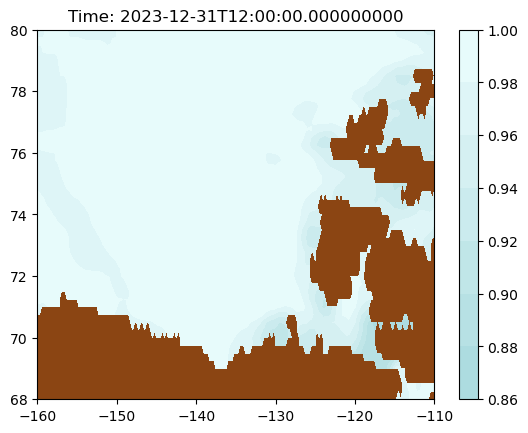

In [87]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from cmocean.cm import ice

sample = ds.where(ds['time.year']==2023, drop=True)

# Function to update the plot for each frame
def update(frame):
    plt.clf()
    ax = plt.gca()
    ax.set_facecolor('saddlebrown')
    plt.contourf(sample.longitude, sample.latitude, sample['siconc'][frame], cmap=ice, vmin=0, vmax=1)
    plt.title(f'Time: {sample.time[frame].values}')
    plt.colorbar()

# Create the animation
animation = FuncAnimation(plt.figure(), update, frames=len(sample.time), interval=1)

# Save the animation as a GIF
animation.save('output_animation.gif', writer='imagemagick', fps=3)

# Show the plot (optional)
plt.show()

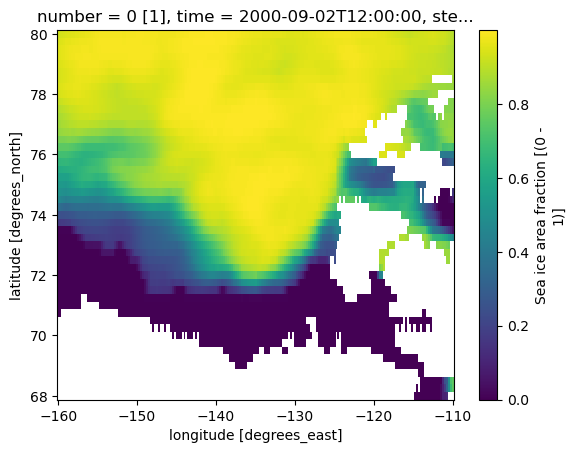

In [68]:
ds.isel(time=1)['siconc'].plot()

In [58]:
ds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', decode_coords={"coordinates"}, drop_variables=['number','step','surface'])
ds

skipping variable: paramId==146 shortName='sshf'
Traceback (most recent call last):
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 680, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 611, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([ 967809600,  967896000,  967982400, ..., 1703851200, 1703937600,
       1704024000])) new_value=Variable(dimensions=('time',), data=array([ 967788000,  967874400,  967960800, ..., 1703829600, 1703916000,
       1704002400]))


<xarray.Dataset> Size: 692MB
Dimensions:     (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time        (time) datetime64[ns] 23kB 2000-09-01T12:00:00 ... 2023-12-31...
  * latitude    (latitude) float64 392B 80.0 79.75 79.5 ... 68.5 68.25 68.0
  * longitude   (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    valid_time  (time) datetime64[ns] 23kB ...
    u10         (time, latitude, longitude) float32 115MB ...
    v10         (time, latitude, longitude) float32 115MB ...
    t2m         (time, latitude, longitude) float32 115MB ...
    lsm         (time, latitude, longitude) float32 115MB ...
    siconc      (time, latitude, longitude) float32 115MB ...
    sp          (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:31 GRIB to CDM+CF via cfgrib-0.9.1...

In [54]:
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', backend_kwargs={'filter_by_keys':{'shortName':'sshf'}}, decode_coords={"coordinates"}, drop_variables=['number','step','surface','valid_time'])
tds

<xarray.Dataset> Size: 115MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T06:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    sshf       (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [57]:
xr.merge((ds, tds))

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 5856, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 47kB 2000-09-01T06:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    u10        (time, latitude, longitude) float32 231MB nan nan ... -10.57
    v10        (time, latitude, longitude) float32 231MB nan nan ... 0.4881
    t2m        (time, latitude, longitude) float32 231MB nan nan ... 258.9 258.7
    lsm        (time, latitude, longitude) float32 231MB nan nan ... 0.4432
    siconc     (time, latitude, longitude) float32 231MB nan nan nan ... nan nan
    sp         (time, latitude, longitude) float32 231MB nan nan ... 1.001e+05
    sshf       (time, latitude, longitude) float32 231MB 1.2e+04 ... nan
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [46]:
datasets = []
for var in ['u10','v10','siconc','t2m','lsm','sp','sshf']:
    datasets.append(xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', backend_kwargs={'filter_by_keys':{'shortName':var}}, decode_coords={"coordinates"}, drop_variables=['number','step','surface','valid_time']))
    
ds = xr.concat(datasets, 0)
ds

TypeError: Index(...) must be called with a collection of some kind, array(0) was passed

In [43]:
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', decode_coords={"coordinates"}, drop_variables=['sshf','step','surface','valid_time'])
tds

skipping variable: paramId==146 shortName='sshf'
Traceback (most recent call last):
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 680, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 611, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([ 967809600,  967896000,  967982400, ..., 1703851200, 1703937600,
       1704024000])) new_value=Variable(dimensions=('time',), data=array([ 967788000,  967874400,  967960800, ..., 1703829600, 1703916000,
       1704002400]))


<xarray.Dataset> Size: 692MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T12:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    number     int64 8B ...
    u10        (time, latitude, longitude) float32 115MB ...
    v10        (time, latitude, longitude) float32 115MB ...
    t2m        (time, latitude, longitude) float32 115MB ...
    lsm        (time, latitude, longitude) float32 115MB ...
    siconc     (time, latitude, longitude) float32 115MB ...
    sp         (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:18 GRIB to CDM+CF via cfgrib-0.9.1...

In [42]:
# read the first set of data
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', backend_kwargs={'filter_by_keys': {('sshf','lsm')}}, decode_coords={"coordinates"}, drop_variables=['number','step','surface','valid_time'])
tds

TypeError: '<' not supported between instances of 'tuple' and 'str'

In [ ]:


ds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib')
# ds = xr.open_dataset('data/buffort_sea_full.nc')

In [ ]:
['u10','v10','siconc','t2m','lsm','sp','sshf']

In [35]:
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', backend_kwargs={'filter_by_keys': {'shortName': 'sshf'}}, decode_coords={"coordinates"}, drop_variables=['number','step','surface','valid_time'])
tds

<xarray.Dataset> Size: 115MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T06:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    sshf       (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [34]:
tds = xr.open_dataset('data/boffort_sea_new.grib', engine='cfgrib', decode_coords={"coordinates"}, drop_variables=['number','step','surface','valid_time'])
tds

skipping variable: paramId==146 shortName='sshf'
Traceback (most recent call last):
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 680, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/Users/kiernan/miniforge3/envs/griber/lib/python3.11/site-packages/cfgrib/dataset.py", line 611, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([ 967809600,  967896000,  967982400, ..., 1703851200, 1703937600,
       1704024000])) new_value=Variable(dimensions=('time',), data=array([ 967788000,  967874400,  967960800, ..., 1703829600, 1703916000,
       1704002400]))


<xarray.Dataset> Size: 692MB
Dimensions:    (time: 2928, latitude: 49, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2000-09-01T12:00:00 ... 2023-12-31T...
  * latitude   (latitude) float64 392B 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 2kB -160.0 -159.8 -159.5 ... -110.2 -110.0
Data variables:
    u10        (time, latitude, longitude) float32 115MB ...
    v10        (time, latitude, longitude) float32 115MB ...
    t2m        (time, latitude, longitude) float32 115MB ...
    lsm        (time, latitude, longitude) float32 115MB ...
    siconc     (time, latitude, longitude) float32 115MB ...
    sp         (time, latitude, longitude) float32 115MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-03-07T11:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [31]:
tds['sshf'].values

KeyError: "No variable named 'sshf'. Variables on the dataset include ['number', 'time', 'step', 'surface', 'latitude', 'longitude', 'valid_time', 'lsm']"

In [2]:
# unobserved land data mask (land mask)
# land frac mask is constant on the grid
# we can get some other masking things and pass to the model separate
# zero the nan values since there is just not ice there

In [3]:
ds['latitude'].min().values, ds['latitude'].max().values

(array(68.), array(80.))

In [4]:
ds['longitude'].min().values, ds['longitude'].max().values

(array(-160.), array(-110.))

In [7]:
df = ds.to_dataframe()

In [8]:
df.head()

number   step  surface  \
time                latitude longitude                           
2000-09-01 12:00:00 80.0     -160.00         0 0 days      0.0   
                             -159.75         0 0 days      0.0   
                             -159.50         0 0 days      0.0   
                             -159.25         0 0 days      0.0   
                             -159.00         0 0 days      0.0   

                                                valid_time       u10  \
time                latitude longitude                                 
2000-09-01 12:00:00 80.0     -160.00   2000-09-01 12:00:00  2.716171   
                             -159.75   2000-09-01 12:00:00  2.762070   
                             -159.50   2000-09-01 12:00:00  2.807968   
                             -159.25   2000-09-01 12:00:00  2.853867   
                             -159.00   2000-09-01 12:00:00  2.913437   

                                             v10         t2m  lsm    siconc  \
time                latitude longitude                                        
2000-09-01 12:00:00 80.0     -160.00    4.687149  273.324707  0.0  0.925446   
                             -159.75    4.762344  273.338379  0.0  0.929932   
                             -159.50    4.837540  273.354004  0.0  0.934448   
                             -159.25    4.911758  273.367676  0.0  0.938934   
                             -159.00    5.033829  273.385254  0.0  0.941284   

                                                 sp  
time                latitude longitude               
2000-09-01 12:00:00 80.0     -160.00    100708.1875  
                             -159.75    100712.1875  
                             -159.50    100717.1875  
                             -159.25    100722.1875  
                             -159.00    100728.1875

In [16]:
nan_count = df.groupby(['latitude','longitude'])['siconc'].apply(lambda x: x.isna().sum())
nan_count.head()

latitude  longitude
68.0      -160.00      2928
          -159.75      2928
          -159.50      2928
          -159.25      2928
          -159.00      2928
Name: siconc, dtype: int64

In [17]:
nan_count.value_counts()

siconc
0       7279
2928    2570
Name: count, dtype: int64

In [5]:
ice = ds['siconc'].values.flatten()
print(ice.shape)
nan_count = np.count_nonzero(~np.isnan(ice))
print(nan_count, nan_count / ice.shape[0])

(28837872,)
21312912 0.7390598030256879


2023-12-31T12:00:00.000000000


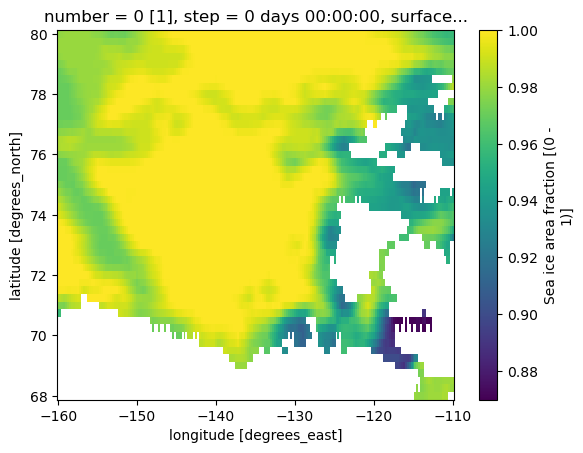

In [6]:
most_recent_date = ds['time'].values[-1]
print(most_recent_date)
sample = ds.sel(time=most_recent_date, drop=True)['siconc']
sample.plot()

In [4]:
ds = ds.where(ds['longitude'] < 0, drop=True)

In [4]:
np.unique(ds['longitude'].values, return_counts=True)

(array([-160.  , -159.75, -159.5 , -159.25, -159.  , -158.75, -158.5 ,
        -158.25, -158.  , -157.75, -157.5 , -157.25, -157.  , -156.75,
        -156.5 , -156.25, -156.  , -155.75, -155.5 , -155.25, -155.  ,
        -154.75, -154.5 , -154.25, -154.  , -153.75, -153.5 , -153.25,
        -153.  , -152.75, -152.5 , -152.25, -152.  , -151.75, -151.5 ,
        -151.25, -151.  , -150.75, -150.5 , -150.25, -150.  , -149.75,
        -149.5 , -149.25, -149.  , -148.75, -148.5 , -148.25, -148.  ,
        -147.75, -147.5 , -147.25, -147.  , -146.75, -146.5 , -146.25,
        -146.  , -145.75, -145.5 , -145.25, -145.  , -144.75, -144.5 ,
        -144.25, -144.  , -143.75, -143.5 , -143.25, -143.  , -142.75,
        -142.5 , -142.25, -142.  , -141.75, -141.5 , -141.25, -141.  ,
        -140.75, -140.5 , -140.25, -140.  , -139.75, -139.5 , -139.25,
        -139.  , -138.75, -138.5 , -138.25, -138.  , -137.75, -137.5 ,
        -137.25, -137.  , -136.75, -136.5 , -136.25, -136.  , -135.75,
      

In [66]:
ds.to_dataframe().describe()

,u10,v10,t2m,lsm,siconc,sp,valid_time,number,step,surface
count,1.109096e+08,1.109096e+08,1.109096e+08,1.109096e+08,8.196882e+07,1.109096e+08,110909589,110909589.0,110909589,110909589.0
mean,-3.077954e-01,-4.364431e-01,2.606452e+02,2.579563e-01,8.175866e-01,1.007217e+05,2008-06-01 12:00:00,0.0,0 days 00:00:00,0.0
min,-2.277559e+01,-2.059749e+01,2.183984e+02,0.000000e+00,0.000000e+00,7.780694e+04,1993-01-01 12:00:00,0.0,0 days 00:00:00,0.0
25%,-3.279922e+00,-2.861145e+00,2.498992e+02,0.000000e+00,8.167114e-01,1.002489e+05,2000-09-16 12:00:00,0.0,0 days 00:00:00,0.0
50%,-2.442780e-01,-5.331573e-01,2.607799e+02,0.000000e+00,9.556580e-01,1.013235e+05,2008-06-01 12:00:00,0.0,0 days 00:00:00,0.0
75%,2.772629e+00,1.975372e+00,2.724475e+02,5.758462e-01,9.918213e-01,1.021546e+05,2016-02-15 12:00:00,0.0,0 days 00:00:00,0.0
max,2.586119e+01,1.976323e+01,2.987961e+02,1.000000e+00,1.000000e+00,1.068179e+05,2023-10-31 12:00:00,0.0,0 days 00:00:00,0.0
std,4.464516e+00,3.645788e+00,1.226541e+01,4.002274e-01,2.998925e-01,2.749954e+03,NaN,0.0,0 days 00:00:00,0.0


2023-12-31T12:00:00.000000000


<xarray.DataArray 'siconc' (latitude: 49, longitude: 200)>
array([[0.97821045, 0.97857666, 0.97891235, ..., 0.9564209 , 0.95687866,
        0.9573059 ],
       [0.980011  , 0.980011  , 0.980011  , ..., 0.9610901 , 0.96066284,
        0.9602356 ],
       [0.980011  , 0.980011  , 0.980011  , ..., 0.97250366, 0.9720764 ,
        0.9714966 ],
       ...,
       [       nan,        nan,        nan, ..., 0.98114014, 0.98114014,
        0.9811096 ],
       [       nan,        nan,        nan, ..., 0.9838562 , 0.982605  ,
        0.98013306],
       [       nan,        nan,        nan, ..., 0.98349   ,        nan,
               nan]], dtype=float32)
Coordinates:
    number     int64 0
    step       timedelta64[ns] 00:00:00
    surface    float64 0.0
  * latitude   (latitude) float64 80.0 79.75 79.5 79.25 ... 68.5 68.25 68.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -110.8 -110.5 -110.2
Attributes: (12/29)
    GRIB_paramId:                             31
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      9849
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_name:                                Sea ice area fraction
    GRIB_shortName:                           ci
    GRIB_units:                               (0 - 1)
    long_name:                                Sea ice area fraction
    units:                                    (0 - 1)
    standard_name:                            sea_ice_area_fraction

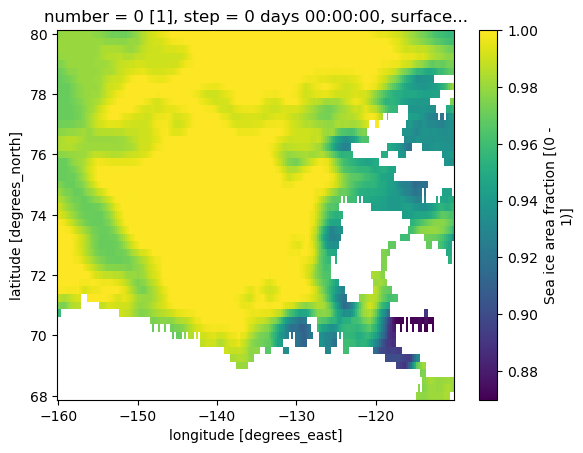

In [5]:
most_recent_date = ds['time'].values[-1]
print(most_recent_date)
sample = ds.sel(time=most_recent_date, drop=True)['siconc']
sample.plot()
sample

In [18]:
df = ds.to_dataframe()
df.head()

number   step  surface valid_time       u10  \
time       latitude longitude                                                
1995-11-01 80.0     -160.00         0 0 days      0.0 1995-11-01  4.195297   
                    -159.75         0 0 days      0.0 1995-11-01  3.549789   
                    -159.50         0 0 days      0.0 1995-11-01  2.904282   
                    -159.25         0 0 days      0.0 1995-11-01  2.257797   
                    -159.00         0 0 days      0.0 1995-11-01  1.533188   

                                    v10         t2m  lsm    siconc  \
time       latitude longitude                                        
1995-11-01 80.0     -160.00   -0.236725  262.816132  0.0  0.928955   
                    -159.75    0.602142  262.890350  0.0  0.932831   
                    -159.50    1.442963  262.962616  0.0  0.936676   
                    -159.25    2.283783  263.036835  0.0  0.940521   
                    -159.00    3.126556  263.073944  0.0  0.943848   

                                        sp  
time       latitude longitude               
1995-11-01 80.0     -160.00    101389.4375  
                    -159.75    101387.4375  
                    -159.50    101385.4375  
                    -159.25    101383.4375  
                    -159.00    101385.4375

In [19]:
df.describe()

,number,step,surface,valid_time,u10,v10,t2m,lsm,siconc,sp
count,472752.0,472752,472752.0,472752,472752.000000,472752.000000,472752.000000,472752.000000,349392.000000,472752.000000
mean,0.0,0 days 00:00:00,0.0,2005-05-02 11:30:00,-1.153742,-1.430906,259.126434,0.257957,0.871342,100121.796875
min,0.0,0 days 00:00:00,0.0,1995-11-01 00:00:00,-12.291641,-16.190750,239.650116,0.000000,0.000000,80820.562500
25%,0.0,0 days 00:00:00,0.0,1995-11-01 11:45:00,-4.155899,-5.119694,254.389652,0.000000,0.850487,100059.437500
50%,0.0,0 days 00:00:00,0.0,2005-05-02 11:30:00,-1.431473,-1.009796,258.677734,0.000000,0.934845,100954.937500
75%,0.0,0 days 00:00:00,0.0,2014-11-01 11:15:00,1.707092,2.660080,264.711334,0.575846,0.978180,101580.125000
max,0.0,0 days 00:00:00,0.0,2014-11-01 23:00:00,17.243866,13.995682,277.440369,1.000000,1.000000,103165.437500
std,0.0,0 days 00:00:00,0.0,NaN,3.934605,5.060359,6.163393,0.400228,0.179335,2742.035400


In [41]:
temp = df.loc[np.isnan(df['siconc'])]
# val_counts = df.index.get_level_values('latitude').value_counts()
# nan_lat_val_counts = temp.index.get_level_values('latitude').value_counts()
# joined = pd.concat((val_counts, nan_lat_val_counts), axis=1)
# joined


,count,count
latitude,,
80.00,9648,NaN
73.75,9648,1680.0
73.25,9648,1776.0
73.00,9648,2160.0
72.75,9648,2496.0
72.50,9648,2736.0
72.25,9648,2880.0
72.00,9648,2688.0
71.75,9648,2496.0


In [23]:
temp = df.loc[df['lsm']==1.0]
print(temp.describe())
temp.head()

       number             step  surface                     valid_time  \
count   912.0              912    912.0                            912   
mean      0.0  0 days 00:00:00      0.0  2005-05-02 11:29:59.999999872   
min       0.0  0 days 00:00:00      0.0            1995-11-01 00:00:00   
25%       0.0  0 days 00:00:00      0.0            1995-11-01 11:45:00   
50%       0.0  0 days 00:00:00      0.0            2005-05-02 11:30:00   
75%       0.0  0 days 00:00:00      0.0            2014-11-01 11:15:00   
max       0.0  0 days 00:00:00      0.0            2014-11-01 23:00:00   
std       0.0  0 days 00:00:00      0.0                            NaN   

              u10         v10         t2m    lsm  siconc             sp  
count  912.000000  912.000000  912.000000  912.0     0.0     912.000000  
mean    -2.171898   -0.936860  259.375641    1.0     NaN   97770.804688  
min     -7.738922  -12.845947  247.492584    1.0     NaN   95333.937500  
25%     -5.170082   -2.980736  255.36

number   step  surface valid_time       u10  \
time       latitude longitude                                                
1995-11-01 75.75    -113.75         0 0 days      0.0 1995-11-01  2.350571   
                    -113.50         0 0 days      0.0 1995-11-01  2.761703   
                    -113.25         0 0 days      0.0 1995-11-01  3.172836   
           74.00    -122.50         0 0 days      0.0 1995-11-01 -4.151382   
                    -122.25         0 0 days      0.0 1995-11-01 -3.670914   

                                    v10         t2m  lsm  siconc           sp  
time       latitude longitude                                                  
1995-11-01 75.75    -113.75    0.859955  249.995819  1.0     NaN   99047.4375  
                    -113.50    0.665619  248.761444  1.0     NaN   99206.4375  
                    -113.25    0.472260  247.527069  1.0     NaN   99366.4375  
           74.00    -122.50    4.601166  251.794647  1.0     NaN  100071.4375  
                    -122.25    4.546478  251.308319  1.0     NaN   99889.4375

In [24]:
temp = df.loc[pd.isna(df['siconc'])]
temp = temp.loc[temp['lsm']<1]
print(temp.shape[0] / df.shape[0])
temp.describe()

0.25901106711341254


,number,step,surface,valid_time,u10,v10,t2m,lsm,siconc,sp
count,122448.0,122448,122448.0,122448,122448.000000,122448.000000,122448.000000,122448.000000,0.0,122448.000000
mean,0.0,0 days 00:00:00,0.0,2005-05-02 11:30:00.000000128,-0.731707,0.039342,259.944061,0.902096,NaN,97205.585938
min,0.0,0 days 00:00:00,0.0,1995-11-01 00:00:00,-12.202774,-14.520523,239.650116,0.226128,NaN,80820.562500
25%,0.0,0 days 00:00:00,0.0,1995-11-01 11:45:00,-3.272709,-2.599895,255.178841,0.879957,NaN,95652.937500
50%,0.0,0 days 00:00:00,0.0,2005-05-02 11:30:00,-1.188568,0.341362,260.104416,0.972173,NaN,98292.937500
75%,0.0,0 days 00:00:00,0.0,2014-11-01 11:15:00,0.930225,3.176826,266.126160,0.996967,NaN,100050.750000
max,0.0,0 days 00:00:00,0.0,2014-11-01 23:00:00,17.159882,13.995682,277.440369,1.000000,NaN,102881.437500
std,0.0,0 days 00:00:00,0.0,NaN,4.091053,4.579907,7.351803,0.149781,NaN,3948.812012


In [29]:
temp = df.loc[pd.isna(df['siconc'])]
temp = temp.loc[temp['lsm']<= 0.3]
print(temp.shape[0] / df.shape[0])
temp.head()

0.0005076657528683116


number   step  surface valid_time       u10  \
time       latitude longitude                                                
1995-11-01 77.25    -112.00         0 0 days      0.0 1995-11-01  3.436508   
                    -111.25         0 0 days      0.0 1995-11-01  3.690414   
           77.00    -120.75         0 0 days      0.0 1995-11-01 -2.437515   
           70.50    -128.50         0 0 days      0.0 1995-11-01 -6.379898   
                    -127.50         0 0 days      0.0 1995-11-01 -7.400406   

                                    v10         t2m       lsm  siconc  \
time       latitude longitude                                           
1995-11-01 77.25    -112.00   -4.165436  249.685272  0.279986     NaN   
                    -111.25   -4.496490  249.952850  0.271202     NaN   
           77.00    -120.75    1.634369  244.698944  0.286107     NaN   
           70.50    -128.50    5.546478  266.900116  0.226128     NaN   
                    -127.50    6.510345  266.974335  0.274858     NaN   

                                        sp  
time       latitude longitude               
1995-11-01 77.25    -112.00    102544.4375  
                    -111.25    102494.4375  
           77.00    -120.75    102681.4375  
           70.50    -128.50    101482.4375  
                    -127.50    101533.4375

In [13]:
temp = df.loc[~pd.isna(df['siconc'])]
temp.describe()

,u10,v10,t2m,lsm,siconc,sp,valid_time,number,step,surface
count,8.196882e+07,8.196882e+07,8.196882e+07,8.196882e+07,8.196882e+07,8.196882e+07,81968819,81968819.0,81968819,81968819.0
mean,-3.623103e-01,-5.408000e-01,2.606396e+02,3.027547e-02,8.175862e-01,1.016774e+05,2008-06-01 11:59:59.999998976,0.0,0 days 00:00:00,0.0
min,-2.277559e+01,-2.059749e+01,2.239766e+02,0.000000e+00,0.000000e+00,9.521025e+04,1993-01-01 12:00:00,0.0,0 days 00:00:00,0.0
25%,-3.764038e+00,-3.222504e+00,2.503595e+02,0.000000e+00,8.167114e-01,1.009632e+05,2000-09-16 12:00:00,0.0,0 days 00:00:00,0.0
50%,-2.733002e-01,-7.211151e-01,2.607391e+02,0.000000e+00,9.556580e-01,1.016714e+05,2008-06-01 12:00:00,0.0,0 days 00:00:00,0.0
75%,3.127411e+00,2.105072e+00,2.722554e+02,0.000000e+00,9.918213e-01,1.023831e+05,2016-02-15 12:00:00,0.0,0 days 00:00:00,0.0
max,2.586119e+01,1.779523e+01,2.961753e+02,8.089261e-01,1.000000e+00,1.068179e+05,2023-10-31 12:00:00,0.0,0 days 00:00:00,0.0
std,4.800588e+00,3.877409e+00,1.126918e+01,1.009348e-01,2.998925e-01,1.103256e+03,NaN,0.0,0 days 00:00:00,0.0
